In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn import svm
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score,  make_scorer, roc_auc_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset
project_root = Path.cwd().parent
data_file = project_root / "framingham.csv"
data = pd.read_csv(data_file)
print(data.head())
print(data.describe())

   male  age  education  currentSmoker  cigsPerDay  BPMeds  prevalentStroke  \
0     1   39        4.0              0         0.0     0.0                0   
1     0   46        2.0              0         0.0     0.0                0   
2     1   48        1.0              1        20.0     0.0                0   
3     0   61        3.0              1        30.0     0.0                0   
4     0   46        3.0              1        23.0     0.0                0   

   prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  heartRate  glucose  \
0             0         0    195.0  106.0   70.0  26.97       80.0     77.0   
1             0         0    250.0  121.0   81.0  28.73       95.0     76.0   
2             0         0    245.0  127.5   80.0  25.34       75.0     70.0   
3             1         0    225.0  150.0   95.0  28.58       65.0    103.0   
4             0         0    285.0  130.0   84.0  23.10       85.0     85.0   

   TenYearCHD  
0           0  
1           0  
2 

### Barplots

**In R, barplots for each category are calculated based on the entire table. To align with this, we have added an option to match R's approach. Additionally, we implemented the functionality to display proportions within each group.**

In [4]:
# Bar plots
def create_bar_plot(variable_counts, variable_name):
    variable_prop = variable_counts.div(variable_counts.sum(1).astype(float), axis=0)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(6, 4))
    
    variable_prop.T.plot(kind='barh', stacked=True, color=["blue", "brown"], ax=ax)
    ax.set_title(f"Heart Disease by {variable_name}")
    ax.set_ylabel(variable_name)
    ax.set_xlabel("Proportion")
    ax.legend(["No Heart Disease", "Heart Disease"])
    
    plt.show()


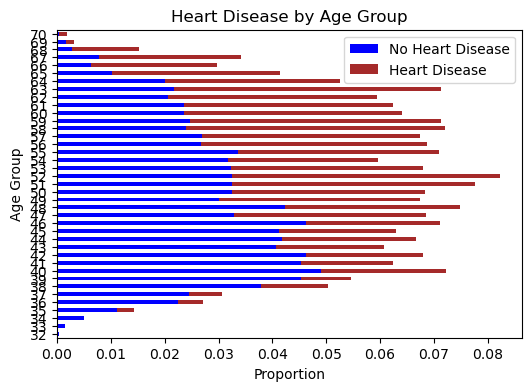

In [5]:
# Bar plot for age
age_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['age'])
create_bar_plot(age_counts, "Age Group")

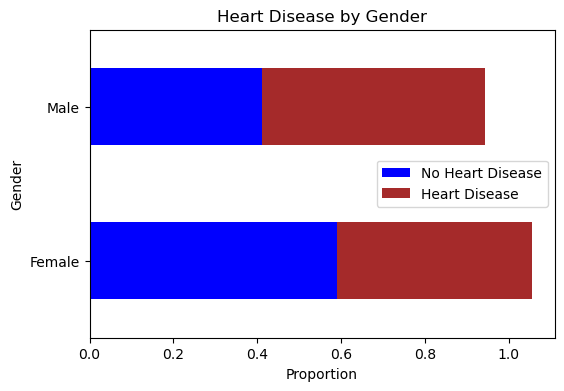

In [6]:
# Bar plot for gender
gender_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['male'])
gender_counts.columns = ["Female", "Male"]
create_bar_plot(gender_counts, "Gender")

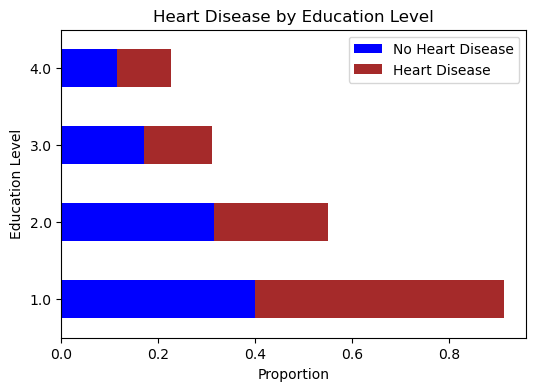

In [7]:
# Bar plot for education level
edu_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['education'])
create_bar_plot(edu_counts, "Education Level")

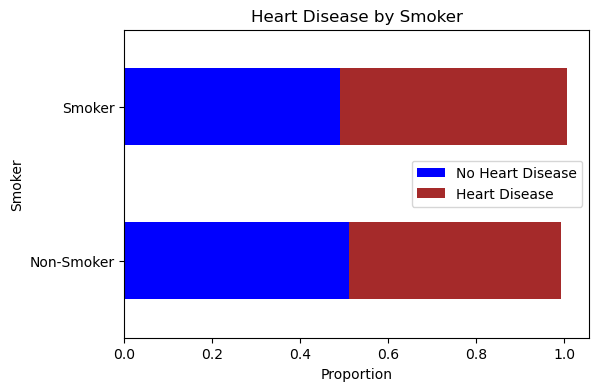

In [8]:
# Bar plot for smokers
smoker_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['currentSmoker'])
smoker_counts.columns = ["Non-Smoker", "Smoker"]
create_bar_plot(smoker_counts, "Smoker")

In [9]:
# Entire table
def create_bar_plot_entire(variable_counts, variable_name):
    # Compute proportions based on the entire dataset
    variable_prop = variable_counts.div(variable_counts.sum().sum().astype(float))

    fig, ax = plt.subplots(figsize=(6, 4))
    variable_prop.T.plot(kind='barh', stacked=True, color=["blue", "brown"], ax=ax)
    ax.set_title(f"Proportion of Heart Disease by {variable_name}")
    ax.set_ylabel(variable_name)
    ax.set_xlabel("Proportion of Total Population")
    ax.legend(["No Heart Disease", "Heart Disease"])
    
    plt.show()

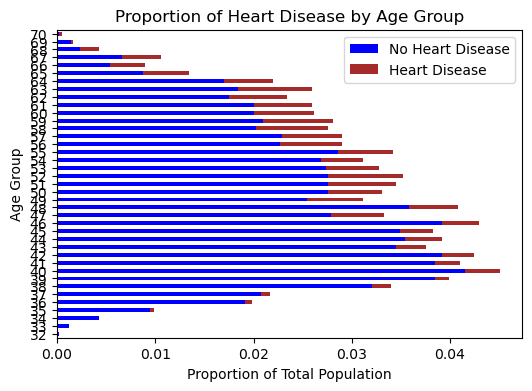

In [10]:
# Bar plot for age - entire table
age_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['age'])
create_bar_plot_entire(age_counts, "Age Group")

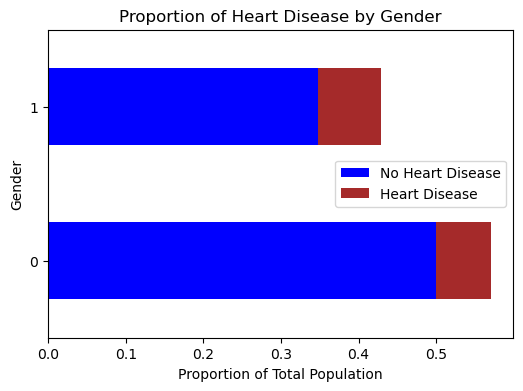

In [11]:
# Bar plot for gender - entire table
age_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['male'])
gender_counts.columns = ["Female", "Male"]
create_bar_plot_entire(age_counts, "Gender")

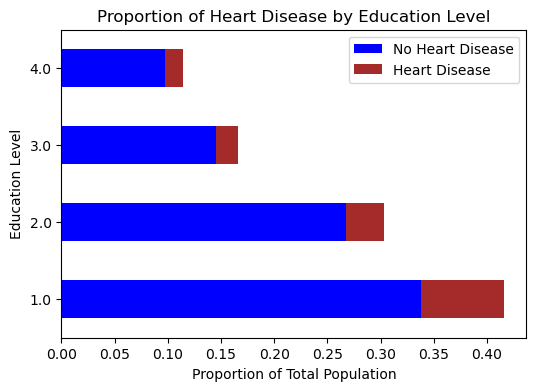

In [12]:
# Bar plot for education level - entire table
edu_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['education'])
create_bar_plot_entire(edu_counts, "Education Level")

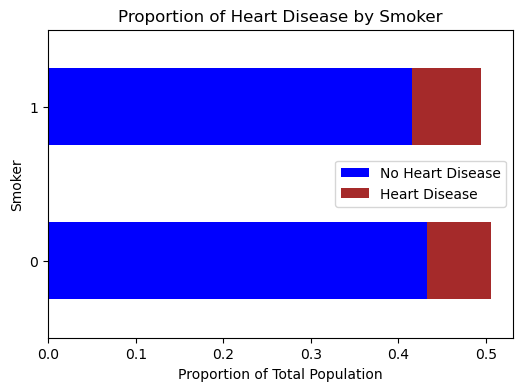

In [13]:
# Bar plot for gender - entire table
smoker_counts = pd.crosstab(index=data['TenYearCHD'], columns=data['currentSmoker'])
create_bar_plot_entire(smoker_counts, "Smoker")

Barplot of CHD vs. age shows younger adults are less likely to have heart disease.

Barplot of CHD vs. gender shows male participants have relativly higher proportion of heart disease.

Barplot of CHD vs. education level shows those participants with 0-11 years of education (category 1 in the plot) have the highest rates of heart disease as compared to High school diploma/GED (or category 2), Some College, Vocational School (or category 3) and College degree or more.

Barplot of CHD vs. current smoking shows smokers have only slightly higher rates of heart disease than non-smokers, somewhere unexpected as smoking has been found to be associated to CHD in other studies.

In [14]:
# # Checking for missing data and imputing with mean of the column where missing
missing_data = data.isnull().sum()

# Imputing missing values with mean of the column
data2 = data.apply(lambda x: x.fillna(x.mean()) if x.dtype != 'object' else x)

# Checking for missing data after imputation
missing_data_after_imputation = data2.isnull().sum()

print("Missing Data Before Imputation:")
print(missing_data)

print("\nMissing Data After Imputation:")
print(missing_data_after_imputation)


Missing Data Before Imputation:
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Missing Data After Imputation:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


We apply data imputation here by replacing the missing values with the average of corresponding column to avoid losing a good percentage of data.

In [15]:
# Changing outcome variable to a factor
data2["TenYearCHD"] = data2["TenYearCHD"].astype("category")

# Renaming the levels for training
data2["TenYearCHD"] = data2["TenYearCHD"].cat.rename_categories({"Class0": 0, "Class1": 1})

X = data2.drop("TenYearCHD", axis=1)
y = data2["TenYearCHD"]


**Class1 is the default positive class in Python for following models**

In [16]:
# Logistic Regression
model_lr_default = LogisticRegression(solver='liblinear')

# Perform cross-validation
accuracy_scores = cross_val_score(model_lr_default, X, y, cv=5, scoring='accuracy')
precision_scores = cross_val_score(model_lr_default, X, y, cv=5, scoring='precision')
recall_scores = cross_val_score(model_lr_default, X, y, cv=5, scoring='recall')
f1_scores = cross_val_score(model_lr_default, X, y, cv=5, scoring='f1')
roc_auc_scores = cross_val_score(model_lr_default, X, y, cv=5, scoring='roc_auc')

# Calculate average metrics
average_metrics_lr_default = {
    "Accuracy": accuracy_scores.mean(),
    "Kappa": None,
    "Sensitivity": recall_scores.mean(),
    "Specificity": None,
    "Pos_Pred_Value": precision_scores.mean(),
    "Neg_Pred_Value": None,
    "Precision": precision_scores.mean(),
    "Recall": recall_scores.mean(),
    "F1": f1_scores.mean(),
    "AUC": roc_auc_scores.mean()
}
average_metrics_lr_default = {
    key: round(value, 4) if value is not None else None 
    for key, value in average_metrics_lr_default.items()
}
print(average_metrics_lr_default)

{'Accuracy': 0.8532, 'Kappa': None, 'Sensitivity': 0.059, 'Specificity': None, 'Pos_Pred_Value': 0.7138, 'Neg_Pred_Value': None, 'Precision': 0.7138, 'Recall': 0.059, 'F1': 0.1087, 'AUC': 0.7191}


In this code, the output measure is "Accuracy" but can be specified any of the accuracy metrics provided in mySummary function defined previously.

The output shows classification accuracy rate, precision, AUC, F1 and Sensitivity. F1 score combines the precision and sensitivity measures into a single one.

While the accuracy measure is about 85%, the sensitivity is very high, 99%. The AUC is 72% however, meaning that we have a 72%  likelihood that the model estimates a random “yes” higher than a random “no”.

In [17]:
#NaiveBayes

model_nb_default = GaussianNB()

# Use cross_val_score for cross-validation
accuracy_scores = cross_val_score(model_nb_default, X, y, cv=5, scoring='accuracy')
precision_scores = cross_val_score(model_nb_default, X, y, cv=5, scoring='precision')
recall_scores = cross_val_score(model_nb_default, X, y, cv=5, scoring='recall')
f1_scores = cross_val_score(model_nb_default, X, y, cv=5, scoring='f1')
roc_auc_scores = cross_val_score(model_nb_default, X, y, cv=5, scoring='roc_auc')

# Calculate average metrics
average_metrics_nb_default = {
    "Accuracy": accuracy_scores.mean(),
    "Kappa": None,
    "Sensitivity": recall_scores.mean(),
    "Specificity": None,
    "Pos_Pred_Value": precision_scores.mean(),
    "Neg_Pred_Value": None,
    "Precision": precision_scores.mean(),
    "Recall": recall_scores.mean(),
    "F1": f1_scores.mean(),
    "AUC": roc_auc_scores.mean()
}

average_metrics_nb_default = {
    key: round(value, 4) if value is not None else None 
    for key, value in average_metrics_nb_default.items()
}

# Print the average metrics
print(average_metrics_nb_default)

{'Accuracy': 0.8233, 'Kappa': None, 'Sensitivity': 0.205, 'Specificity': None, 'Pos_Pred_Value': 0.3566, 'Neg_Pred_Value': None, 'Precision': 0.3566, 'Recall': 0.205, 'F1': 0.2597, 'AUC': 0.7118}


The method changes to naïve_bayes. The classification accuracy and the AUC are slightly lower than for logistic regression.

In [18]:
#Decision Tree
model_dt_default = DecisionTreeClassifier(random_state=123)

# Use cross_val_score for cross-validation
accuracy_scores = cross_val_score(model_dt_default, X, y, cv=5, scoring='accuracy')
precision_scores = cross_val_score(model_dt_default, X, y, cv=5, scoring='precision')
recall_scores = cross_val_score(model_dt_default, X, y, cv=5, scoring='recall')
f1_scores = cross_val_score(model_dt_default, X, y, cv=5, scoring='f1')
roc_auc_scores = cross_val_score(model_dt_default, X, y, cv=5, scoring='roc_auc')

# Calculate average metrics
average_metrics_dt_default = {
    "Accuracy": accuracy_scores.mean(),
    "Kappa": None,
    "Sensitivity": recall_scores.mean(),
    "Specificity": None,
    "Pos_Pred_Value": precision_scores.mean(),
    "Neg_Pred_Value": None,
    "Precision": precision_scores.mean(),
    "Recall": recall_scores.mean(),
    "F1": f1_scores.mean(),
    "AUC": roc_auc_scores.mean()
}

average_metrics_dt_default = {
    key: round(value, 4) if value is not None else None 
    for key, value in average_metrics_dt_default.items()
}

# Print the average metrics
print(average_metrics_dt_default)

{'Accuracy': 0.7581, 'Kappa': None, 'Sensitivity': 0.2639, 'Specificity': None, 'Pos_Pred_Value': 0.2354, 'Neg_Pred_Value': None, 'Precision': 0.2354, 'Recall': 0.2639, 'F1': 0.2488, 'AUC': 0.5553}


In [19]:
#Random Forest
model_rf_default = RandomForestClassifier(random_state=123)

# Use cross_val_score for cross-validation
accuracy_scores = cross_val_score(model_rf_default, X, y, cv=5, scoring='accuracy')
precision_scores = cross_val_score(model_rf_default, X, y, cv=5, scoring='precision')
recall_scores = cross_val_score(model_rf_default, X, y, cv=5, scoring='recall')
f1_scores = cross_val_score(model_rf_default, X, y, cv=5, scoring='f1')
roc_auc_scores = cross_val_score(model_rf_default, X, y, cv=5, scoring='roc_auc')

# Calculate average metrics
average_metrics_rf_default = {
    "Accuracy": accuracy_scores.mean(),
    "Kappa": None,
    "Sensitivity": recall_scores.mean(),
    "Specificity": None,
    "Pos_Pred_Value": precision_scores.mean(),
    "Neg_Pred_Value": None,
    "Precision": precision_scores.mean(),
    "Recall": recall_scores.mean(),
    "F1": f1_scores.mean(),
    "AUC": roc_auc_scores.mean()
}

average_metrics_rf_default = {
    key: round(value, 4) if value is not None else None 
    for key, value in average_metrics_rf_default.items()
}

# Print the average metrics
print(average_metrics_rf_default)

{'Accuracy': 0.8476, 'Kappa': None, 'Sensitivity': 0.0497, 'Specificity': None, 'Pos_Pred_Value': 0.4899, 'Neg_Pred_Value': None, 'Precision': 0.4899, 'Recall': 0.0497, 'F1': 0.0901, 'AUC': 0.6974}


In [20]:
#XGBoost
model_xgb_default = XGBClassifier(random_state=123)

# Use cross_val_score for cross-validation
accuracy_scores = cross_val_score(model_xgb_default, X, y, cv=5, scoring='accuracy')
precision_scores = cross_val_score(model_xgb_default, X, y, cv=5, scoring='precision')
recall_scores = cross_val_score(model_xgb_default, X, y, cv=5, scoring='recall')
f1_scores = cross_val_score(model_xgb_default, X, y, cv=5, scoring='f1')
roc_auc_scores = cross_val_score(model_xgb_default, X, y, cv=5, scoring='roc_auc')

# Calculate average metrics
average_metrics_xgb_default = {
    "Accuracy": accuracy_scores.mean(),
    "Kappa": None,
    "Sensitivity": recall_scores.mean(),
    "Specificity": None,
    "Pos_Pred_Value": precision_scores.mean(),
    "Neg_Pred_Value": None,
    "Precision": precision_scores.mean(),
    "Recall": recall_scores.mean(),
    "F1": f1_scores.mean(),
    "AUC": roc_auc_scores.mean()
}

average_metrics_xgb_default = {
    key: round(value, 4) if value is not None else None 
    for key, value in average_metrics_xgb_default.items()
}

# Print the average metrics
print(average_metrics_xgb_default)

{'Accuracy': 0.8336, 'Kappa': None, 'Sensitivity': 0.1397, 'Specificity': None, 'Pos_Pred_Value': 0.3781, 'Neg_Pred_Value': None, 'Precision': 0.3781, 'Recall': 0.1397, 'F1': 0.2037, 'AUC': 0.6425}


In [21]:
# Normalize data for SVM
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

model_svm_default = SVC(kernel='rbf', random_state=123)

# Use cross_val_score for cross-validation
accuracy_scores = cross_val_score(model_svm_default, scaled_X, y, cv=5, scoring='accuracy')
precision_scores = cross_val_score(model_svm_default, scaled_X, y, cv=5, scoring='precision')
recall_scores = cross_val_score(model_svm_default, scaled_X, y, cv=5, scoring='recall')
f1_scores = cross_val_score(model_svm_default, scaled_X, y, cv=5, scoring='f1')
roc_auc_scores = cross_val_score(model_svm_default, scaled_X, y, cv=5, scoring='roc_auc')

# Calculate average metrics
average_metrics_svm_default = {
    "Accuracy": accuracy_scores.mean(),
    "Kappa": None,
    "Sensitivity": recall_scores.mean(),
    "Specificity": None,
    "Pos_Pred_Value": precision_scores.mean(),
    "Neg_Pred_Value": None,
    "Precision": precision_scores.mean(),
    "Recall": recall_scores.mean(),
    "F1": f1_scores.mean(),
    "AUC": roc_auc_scores.mean()
}
average_metrics_svm_default = {
    key: round(value, 4) if value is not None else None 
    for key, value in average_metrics_svm_default.items()
}

# Print the average metrics
print(average_metrics_svm_default)

{'Accuracy': 0.8483, 'Kappa': None, 'Sensitivity': 0.0171, 'Specificity': None, 'Pos_Pred_Value': 0.4911, 'Neg_Pred_Value': None, 'Precision': 0.4911, 'Recall': 0.0171, 'F1': 0.0326, 'AUC': 0.611}


All six methods show similar results in terms of accuracy. However, regarding AUC, logistic regression and naïve_bayes seem to perform best.

It's recommended to consider multiple accuracy measures to evaluate accross models because some measures might have similar performance. Meanwhile, machine learning methods do not necessarily perform better than logistic regression.